In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR, SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('D:\\ML PROJECTS\\AML lab\\dataset\\HistoricalQuotes.csv')

=== SVM REGRESSION ANALYSIS ===

Training SVM with linear kernel...
  MSE: 9.5713
  RMSE: 3.0938
  MAE: 2.0600

Training SVM with rbf kernel...
  MSE: 8082.0549
  RMSE: 89.9002
  MAE: 64.3955

Training SVM with poly kernel...
  MSE: 305475.9823
  RMSE: 552.6988
  MAE: 298.2625

Best kernel: linear (RMSE: 3.0938)

=== SVM CLASSIFICATION ANALYSIS ===

Training SVM Classifier with linear kernel...
  Accuracy: 0.9920
  Classification Report:
              precision    recall  f1-score   support

        Down       0.99      1.00      0.99       227
          Up       1.00      0.99      0.99       273

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500


Training SVM Classifier with rbf kernel...
  Accuracy: 0.8080
  Classification Report:
              precision    recall  f1-score   support

        Down       0.71      0.99      0.82       227
          Up       0.98      0.66 

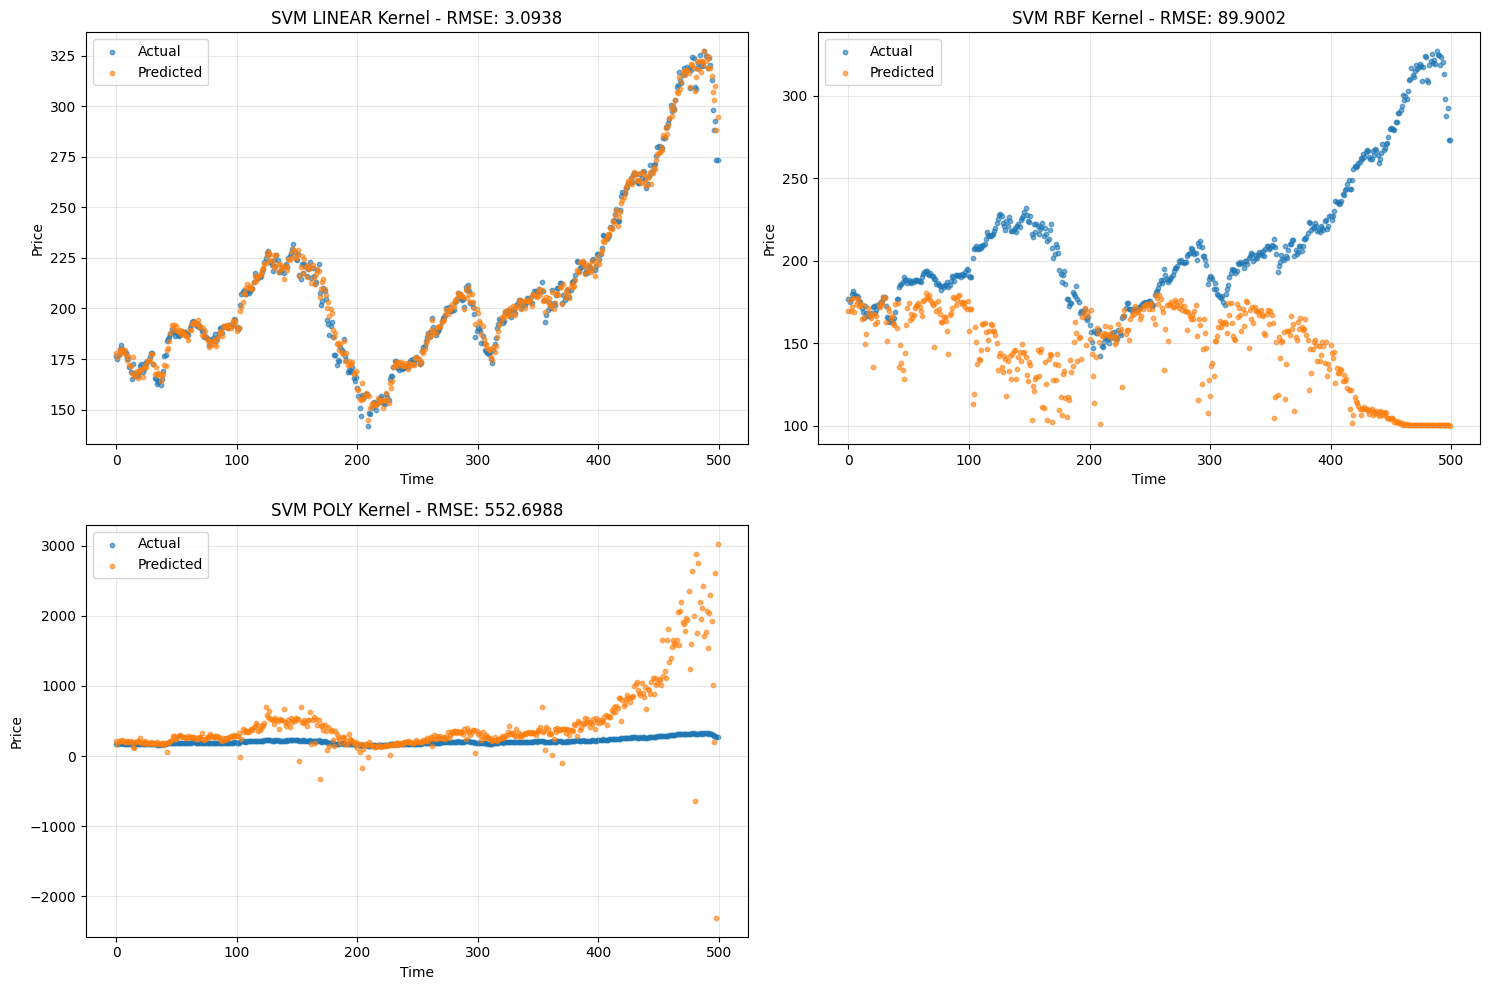

In [24]:


# Load and preprocess the data
def preprocess_data(df):
    """
    Preprocess the stock data by converting price columns to numeric
    and creating additional features
    """
    # Create a copy to avoid modifying original data
    data = df.copy()
    
    # Convert Date to datetime
    data['Date'] = pd.to_datetime(data['Date'])
    
    # Clean and convert price columns (remove $ signs and convert to float)
    price_columns = [' Close/Last', ' Open', ' High', ' Low']
    for col in price_columns:
        if col in data.columns:
            # Remove $ sign and convert to float
            data[col] = data[col].str.replace('$', '').astype(float)
    
    # Sort by date
    data = data.sort_values('Date').reset_index(drop=True)
    
    return data

def create_features(data):
    """
    Create technical indicators and features for SVM
    """
    # Calculate moving averages
    data['MA_5'] = data[' Close/Last'].rolling(window=5).mean()
    data['MA_10'] = data[' Close/Last'].rolling(window=10).mean()
    data['MA_20'] = data[' Close/Last'].rolling(window=20).mean()
    
    # Calculate price changes
    data['Price_Change'] = data[' Close/Last'].diff()
    data['Price_Change_Pct'] = data[' Close/Last'].pct_change()
    
    # Calculate volatility (rolling standard deviation)
    data['Volatility'] = data[' Close/Last'].rolling(window=10).std()
    
    # Calculate RSI (Relative Strength Index)
    delta = data[' Close/Last'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
    
    # High-Low spread
    data['HL_Spread'] = data[' High'] - data[' Low']
    
    # Open-Close spread
    data['OC_Spread'] = data[' Close/Last'] - data[' Open']
    
    # Volume features
    data['Volume_MA'] = data[' Volume'].rolling(window=10).mean()
    data['Volume_Ratio'] = data[' Volume'] / data['Volume_MA']
    
    # Lagged features
    for lag in [1, 2, 3, 5]:
        data[f'Close_Lag_{lag}'] = data[' Close/Last'].shift(lag)
        data[f'Volume_Lag_{lag}'] = data[' Volume'].shift(lag)
    
    return data

def svm_regression_analysis(data):
    """
    Perform SVM regression to predict stock prices
    """
    print("=== SVM REGRESSION ANALYSIS ===")
    
    # Create features
    feature_columns = ['MA_5', 'MA_10', 'MA_20', 'Price_Change', 'Price_Change_Pct',
                      'Volatility', 'RSI', 'HL_Spread', 'OC_Spread', ' Volume',
                      'Volume_Ratio', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3',
                      'Close_Lag_5', 'Volume_Lag_1', 'Volume_Lag_2']
    
    # Remove rows with NaN values
    clean_data = data.dropna()
    
    # Prepare features and target
    X = clean_data[feature_columns]
    y = clean_data[' Close/Last']  # Predict closing price
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False  # Don't shuffle for time series
    )
    
    # Scale the features
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # Scale the target variable
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    
    # Train SVM with different kernels
    kernels = ['linear', 'rbf', 'poly']
    results = {}
    
    for kernel in kernels:
        print(f"\nTraining SVM with {kernel} kernel...")
        
        # Create and train SVM
        if kernel == 'linear':
            svm_model = SVR(kernel=kernel, C=1.0)
        elif kernel == 'rbf':
            svm_model = SVR(kernel=kernel, C=1.0, gamma='scale')
        else:  # poly
            svm_model = SVR(kernel=kernel, C=1.0, degree=3)
        
        svm_model.fit(X_train_scaled, y_train_scaled)
        
        # Make predictions
        y_pred_scaled = svm_model.predict(X_test_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        
        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        
        results[kernel] = {
            'model': svm_model,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'predictions': y_pred
        }
        
        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE: {mae:.4f}")
    
    # Find best model
    best_kernel = min(results.keys(), key=lambda k: results[k]['rmse'])
    print(f"\nBest kernel: {best_kernel} (RMSE: {results[best_kernel]['rmse']:.4f})")
    
    return results, X_test, y_test, scaler_X, scaler_y

def svm_classification_analysis(data):
    """
    Perform SVM classification to predict price direction (Up/Down)
    """
    print("\n=== SVM CLASSIFICATION ANALYSIS ===")
    
    # Create target variable (price direction)
    data['Price_Direction'] = np.where(data['Price_Change'] > 0, 1, 0)  # 1 for up, 0 for down
    
    # Create features
    feature_columns = ['MA_5', 'MA_10', 'MA_20', 'Price_Change_Pct',
                      'Volatility', 'RSI', 'HL_Spread', 'OC_Spread', ' Volume',
                      'Volume_Ratio', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3']
    
    # Remove rows with NaN values
    clean_data = data.dropna()
    
    # Prepare features and target
    X = clean_data[feature_columns]
    y = clean_data['Price_Direction']
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    
    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train SVM classifier with different kernels
    kernels = ['linear', 'rbf', 'poly']
    classification_results = {}
    
    for kernel in kernels:
        print(f"\nTraining SVM Classifier with {kernel} kernel...")
        
        # Create and train SVM classifier
        if kernel == 'linear':
            svm_classifier = SVC(kernel=kernel, C=1.0, random_state=42)
        elif kernel == 'rbf':
            svm_classifier = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
        else:  # poly
            svm_classifier = SVC(kernel=kernel, C=1.0, degree=3, random_state=42)
        
        svm_classifier.fit(X_train_scaled, y_train)
        
        # Make predictions
        y_pred = svm_classifier.predict(X_test_scaled)
        
        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        
        classification_results[kernel] = {
            'model': svm_classifier,
            'accuracy': accuracy,
            'predictions': y_pred
        }
        
        print(f"  Accuracy: {accuracy:.4f}")
        print("  Classification Report:")
        print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))
    
    # Find best classifier
    best_kernel = max(classification_results.keys(), key=lambda k: classification_results[k]['accuracy'])
    print(f"\nBest classifier kernel: {best_kernel} (Accuracy: {classification_results[best_kernel]['accuracy']:.4f})")
    
    return classification_results

def hyperparameter_tuning(X_train, y_train):
    """
    Perform hyperparameter tuning for SVM
    """
    print("\n=== HYPERPARAMETER TUNING ===")
    
    # Define parameter grid
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    }
    
    # Create SVM
    svm = SVR()
    
    # Perform grid search
    grid_search = GridSearchCV(
        svm, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_

def plot_results(results, X_test, y_test):
    """
    Plot the results of SVM regression
    """
    plt.figure(figsize=(15, 10))
    
    for i, (kernel, result) in enumerate(results.items(), 1):
        plt.subplot(2, 2, i)
        plt.scatter(range(len(y_test)), y_test, alpha=0.6, label='Actual', s=10)
        plt.scatter(range(len(result['predictions'])), result['predictions'], 
                   alpha=0.6, label='Predicted', s=10)
        plt.title(f'SVM {kernel.upper()} Kernel - RMSE: {result["rmse"]:.4f}')
        plt.xlabel('Time')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Main execution function
def main():
    """
    Main function to execute the SVM analysis
    """
    # Note: Replace 'your_dataset.csv' with your actual file path
    df = pd.read_csv('D:\\ML PROJECTS\\AML lab\\dataset\\HistoricalQuotes.csv')
    
    # For demonstration, create sample data structure
    # print("Please load your dataset using:")
    # print("df = pd.read_csv('your_dataset_file.csv')")
    # print("\nThen run the following functions:")
    # print("1. data = preprocess_data(df)")
    # print("2. data = create_features(data)")
    # print("3. regression_results, X_test, y_test, scaler_X, scaler_y = svm_regression_analysis(data)")
    # print("4. classification_results = svm_classification_analysis(data)")
    # print("5. plot_results(regression_results, X_test, y_test)")
    data = preprocess_data(df)
    data = create_features(data)
    regression_results, X_test, y_test, scaler_X, scaler_y = svm_regression_analysis(data)
    classification_results = svm_classification_analysis(data)
    plot_results(regression_results, X_test, y_test)


    

if __name__ == "__main__":
    main()

=== SVM REGRESSION ANALYSIS ===

Training SVM with linear kernel...
  MSE: 9.5713
  RMSE: 3.0938
  MAE: 2.0600

Training SVM with rbf kernel...
  MSE: 8082.0549
  RMSE: 89.9002
  MAE: 64.3955

Training SVM with poly kernel...
  MSE: 305475.9823
  RMSE: 552.6988
  MAE: 298.2625

Best kernel: linear (RMSE: 3.0938)

=== SVM CLASSIFICATION ANALYSIS ===

Training SVM Classifier with linear kernel...
  Accuracy: 0.9920
  Classification Report:
              precision    recall  f1-score   support

        Down       0.99      1.00      0.99       227
          Up       1.00      0.99      0.99       273

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500


Training SVM Classifier with rbf kernel...
  Accuracy: 0.8080
  Classification Report:
              precision    recall  f1-score   support

        Down       0.71      0.99      0.82       227
          Up       0.98      0.66 

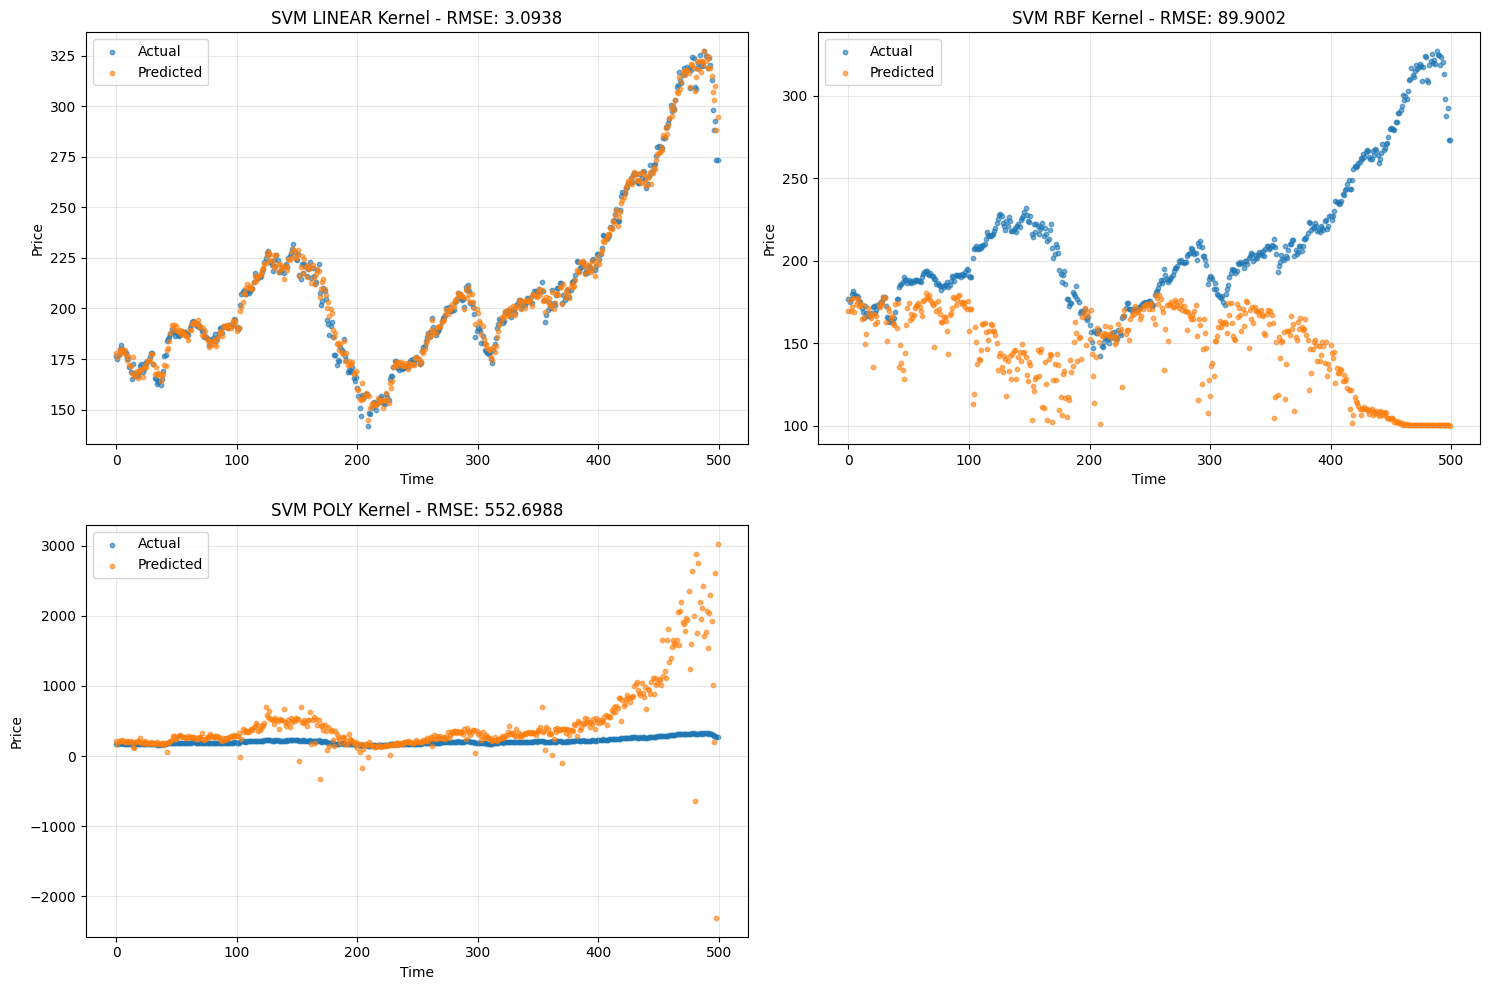

In [25]:
# Example usage (uncomment when you have the data):
   
 # Load and preprocess data
df = pd.read_csv('D:\\ML PROJECTS\\AML lab\\dataset\\HistoricalQuotes.csv')
data = preprocess_data(df)
data = create_features(data)

# Perform SVM regression analysis
regression_results, X_test, y_test, scaler_X, scaler_y = svm_regression_analysis(data)

# Perform SVM classification analysis
classification_results = svm_classification_analysis(data)

# Plot results
plot_results(regression_results, X_test, y_test)

# Optional: Hyperparameter tuning
#best_model = hyperparameter_tuning(X_train_scaled, y_train_scaled)


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, SVC
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pylab as py
from sklearn.model_selection import GridSearchCV


# Load and preprocess the data
def preprocess_data(df):
    """
    Preprocess the stock data by converting price columns to numeric
    and creating additional features
    """
    # Create a copy to avoid modifying original data
    data = df.copy()

    # Convert Date to datetime
    data['Date'] = pd.to_datetime(data['Date'])

    # Clean and convert price columns (remove $ signs and convert to float)
    price_columns = [' Close/Last', ' Open', ' High', ' Low']
    for col in price_columns:
        if col in data.columns:
            # Remove $ sign and convert to float
            data[col] = data[col].str.replace('$', '').astype(float)

    # Sort by date
    data = data.sort_values('Date').reset_index(drop=True)

    return data

def create_features(data):
    """
    Create technical indicators and features for SVM
    """
    # Calculate moving averages
    data['MA_5'] = data[' Close/Last'].rolling(window=5).mean()
    data['MA_10'] = data[' Close/Last'].rolling(window=10).mean()
    data['MA_20'] = data[' Close/Last'].rolling(window=20).mean()

    # Calculate price changes
    data['Price_Change'] = data[' Close/Last'].diff()
    data['Price_Change_Pct'] = data[' Close/Last'].pct_change()

    # Calculate volatility (rolling standard deviation)
    data['Volatility'] = data[' Close/Last'].rolling(window=10).std()

    # Calculate RSI (Relative Strength Index)
    delta = data[' Close/Last'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))

    # High-Low spread
    data['HL_Spread'] = data[' High'] - data[' Low']

    # Open-Close spread
    data['OC_Spread'] = data[' Close/Last'] - data[' Open']

    # Volume features
    data['Volume_MA'] = data[' Volume'].rolling(window=10).mean()
    data['Volume_Ratio'] = data[' Volume'] / data['Volume_MA']

    # Lagged features
    for lag in [1, 2, 3, 5]:
        data[f'Close_Lag_{lag}'] = data[' Close/Last'].shift(lag)
        data[f'Volume_Lag_{lag}'] = data[' Volume'].shift(lag)

    return data

def svm_regression_analysis(data):
    """
    Perform SVM regression to predict stock prices
    """
    print("=== SVM REGRESSION ANALYSIS ===")

    # Create features
    feature_columns = ['MA_5', 'MA_10', 'MA_20', 'Price_Change', 'Price_Change_Pct',
                      'Volatility', 'RSI', 'HL_Spread', 'OC_Spread', ' Volume',
                      'Volume_Ratio', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3',
                      'Close_Lag_5', 'Volume_Lag_1', 'Volume_Lag_2']

    # Remove rows with NaN values
    clean_data = data.dropna()

    # Prepare features and target
    X = clean_data[feature_columns]
    y = clean_data[' Close/Last']  # Predict closing price

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False  # Don't shuffle for time series
    )

    # Scale the features
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # Scale the target variable
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Train SVM with different kernels
    kernels = ['linear', 'rbf', 'poly']
    results = {}

    for kernel in kernels:
        print(f"\nTraining SVM with {kernel} kernel...")

        # Create and train SVM
        if kernel == 'linear':
            svm_model = SVR(kernel=kernel, C=1.0)
        elif kernel == 'rbf':
            svm_model = SVR(kernel=kernel, C=1.0, gamma='scale')
        else:  # poly
            svm_model = SVR(kernel=kernel, C=1.0, degree=3)

        svm_model.fit(X_train_scaled, y_train_scaled)

        # Make predictions
        y_pred_scaled = svm_model.predict(X_test_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)

        results[kernel] = {
            'model': svm_model,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'predictions': y_pred
        }

        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE: {mae:.4f}")

    # Find best model
    best_kernel = min(results.keys(), key=lambda k: results[best_kernel]['rmse'])
    print(f"\nBest kernel: {best_kernel} (RMSE: {results[best_kernel]['rmse']:.4f})")

    return results, X_test, y_test, scaler_X, scaler_y

def svm_classification_analysis(data):
    """
    Perform SVM classification to predict price direction (Up/Down)
    """
    print("\n=== SVM CLASSIFICATION ANALYSIS ===")

    # Create target variable (price direction)
    data['Price_Direction'] = np.where(data['Price_Change'] > 0, 1, 0)  # 1 for up, 0 for down

    # Create features
    feature_columns = ['MA_5', 'MA_10', 'MA_20', 'Price_Change_Pct',
                      'Volatility', 'RSI', 'HL_Spread', 'OC_Spread', ' Volume',
                      'Volume_Ratio', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3']

    # Remove rows with NaN values
    clean_data = data.dropna()

    # Prepare features and target
    X = clean_data[feature_columns]
    y = clean_data['Price_Direction']

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVM classifier with different kernels
    kernels = ['linear', 'rbf', 'poly']
    classification_results = {}

    for kernel in kernels:
        print(f"\nTraining SVM Classifier with {kernel} kernel...")

        # Create and train SVM classifier
        if kernel == 'linear':
            svm_classifier = SVC(kernel=kernel, C=1.0, random_state=42)
        elif kernel == 'rbf':
            svm_classifier = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42, probability=True) # probability=True needed for ROC
        else:  # poly
            svm_classifier = SVC(kernel=kernel, C=1.0, degree=3, random_state=42, probability=True) # probability=True needed for ROC

        svm_classifier.fit(X_train_scaled, y_train)

        # Make predictions
        y_pred = svm_classifier.predict(X_test_scaled)
        y_pred_proba = svm_classifier.predict_proba(X_test_scaled)[:, 1] # Get probabilities for ROC

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)

        classification_results[kernel] = {
            'model': svm_classifier,
            'accuracy': accuracy,
            'predictions': y_pred,
            'probabilities': y_pred_proba # Store probabilities
        }

        print(f"  Accuracy: {accuracy:.4f}")
        print("  Classification Report:")
        print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))

        # Plot Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix - {kernel.upper()} Kernel')
        plt.colorbar()
        tick_marks = np.arange(len(['Down', 'Up']))
        plt.xticks(tick_marks, ['Down', 'Up'], rotation=45)
        plt.yticks(tick_marks, ['Down', 'Up'])
        plt.ylabel('Actual label')
        plt.xlabel('Predicted label')
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], 'd'),
                         ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2. else "black")
        plt.tight_layout()
        plt.show()

        # Plot ROC Curve
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic (ROC) Curve - {kernel.upper()} Kernel')
        plt.legend(loc="lower right")
        plt.show()


    # Find best classifier
    best_kernel = max(classification_results.keys(), key=lambda k: classification_results[k]['accuracy'])
    print(f"\nBest classifier kernel: {best_kernel} (Accuracy: {classification_results[best_kernel]['accuracy']:.4f})")

    return classification_results

def hyperparameter_tuning(X_train, y_train):
    """
    Perform hyperparameter tuning for SVM
    """
    print("\n=== HYPERPARAMETER TUNING ===")

    # Define parameter grid
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    }

    # Create SVM
    svm = SVR()

    # Perform grid search
    grid_search = GridSearchCV(
        svm, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

    return grid_search.best_estimator_

def plot_results(results, X_test, y_test):
    """
    Plot the results of SVM regression
    """
    plt.figure(figsize=(15, 10))

    for i, (kernel, result) in enumerate(results.items(), 1):
        plt.subplot(2, 2, i)
        plt.scatter(range(len(y_test)), y_test, alpha=0.6, label='Actual', s=10)
        plt.scatter(range(len(result['predictions'])), result['predictions'],
                   alpha=0.6, label='Predicted', s=10)
        plt.title(f'SVM {kernel.upper()} Kernel - RMSE: {result["rmse"]:.4f}')
        plt.xlabel('Time')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Main execution function
def main():
    """
    Main function to execute the SVM analysis
    """
    # Note: Replace 'your_dataset.csv' with your actual file path
    # df = pd.read_csv('your_dataset.csv')

    # For demonstration, create sample data structure
    df = pd.read_csv('D:\\ML PROJECTS\\AML lab\\dataset\\HistoricalQuotes.csv')
    # print("Please load your dataset using:")
    # print("df = pd.read_csv('your_dataset_file.csv')")
    # print("\nThen run the following functions:")
    # print("1. data = preprocess_data(df)")
    # print("2. data = create_features(data)")
    # print("3. regression_results, X_test_reg, y_test_reg, scaler_X_reg, scaler_y_reg = svm_regression_analysis(data)")
    # print("4. classification_results = svm_classification_analysis(data)")
    # print("5. plot_results(regression_results, X_test_reg, y_test_reg)")
    data = preprocess_data(df)

    #df = pd.read_csv('D:\\ML PROJECTS\\AML lab\\dataset\\HistoricalQuotes.csv')
    
    # For demonstration, create sample data structure
    # print("Please load your dataset using:")
    # print("df = pd.read_csv('your_dataset_file.csv')")
    # print("\nThen run the following functions:")
    # print("1. data = preprocess_data(df)")
    # print("2. data = create_features(data)")
    # print("3. regression_results, X_test, y_test, scaler_X, scaler_y = svm_regression_analysis(data)")
    # print("4. classification_results = svm_classification_analysis(data)")
    # print("5. plot_results(regression_results, X_test, y_test)")
    data = preprocess_data(df)
    data = create_features(data)
    regression_results, X_test_reg, y_test_reg, scaler_X_reg, scaler_y_reg = svm_regression_analysis(data)
    classification_results = svm_classification_analysis(data)
    plot_results(regression_results, X_test, y_test)
    
    



if __name__ == "__main__":
    main()

=== SVM REGRESSION ANALYSIS ===

Training SVM with linear kernel...
  MSE: 9.5713
  RMSE: 3.0938
  MAE: 2.0600

Training SVM with rbf kernel...
  MSE: 8082.0549
  RMSE: 89.9002
  MAE: 64.3955

Training SVM with poly kernel...
  MSE: 305475.9823
  RMSE: 552.6988
  MAE: 298.2625


NameError: free variable 'best_kernel' referenced before assignment in enclosing scope

In [8]:
# Example usage (uncomment when you have the data):
   
 # Load and preprocess data
df = pd.read_csv('D:\\ML PROJECTS\\AML lab\\dataset\\HistoricalQuotes.csv')
data = preprocess_data(df)
data = create_features(data)

# Perform SVM regression analysis
regression_results, X_test, y_test, scaler_X, scaler_y = svm_regression_analysis(data)

# Perform SVM classification analysis
classification_results = svm_classification_analysis(data)

# Plot results
plot_results(regression_results, X_test, y_test)

# Optional: Hyperparameter tuning
#best_model = hyperparameter_tuning(X_train_scaled, y_train_scaled)


=== SVM REGRESSION ANALYSIS ===

Training SVM with linear kernel...
  MSE: 9.5713
  RMSE: 3.0938
  MAE: 2.0600

Training SVM with rbf kernel...
  MSE: 8082.0549
  RMSE: 89.9002
  MAE: 64.3955

Training SVM with poly kernel...
  MSE: 305475.9823
  RMSE: 552.6988
  MAE: 298.2625


NameError: free variable 'best_kernel' referenced before assignment in enclosing scope

In [5]:
# Plot Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix - {kernel.upper()} Kernel')
        plt.colorbar()
        tick_marks = np.arange(len(['Down', 'Up']))
        plt.xticks(tick_marks, ['Down', 'Up'], rotation=45)
        plt.yticks(tick_marks, ['Down', 'Up'])
        plt.ylabel('Actual label')
        plt.xlabel('Predicted label')
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], 'd'),
                         ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2. else "black")
        plt.tight_layout()
        plt.show()

        # Plot ROC Curve
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic (ROC) Curve - {kernel.upper()} Kernel')
        plt.legend(loc="lower right")
        plt.show()

IndentationError: unexpected indent (134927183.py, line 2)